In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline



In [85]:
x=6*np.random.rand(100,1)-3
y=0.5 * x**2+1.5*x+2+np.random.randn(100,1)

## here we used a quadratic equation to get non_linear data ax^2+bx+c=0 where (0.5X^2+1.5X+C+Outliers)

Text(0, 0.5, 'Y dataset')

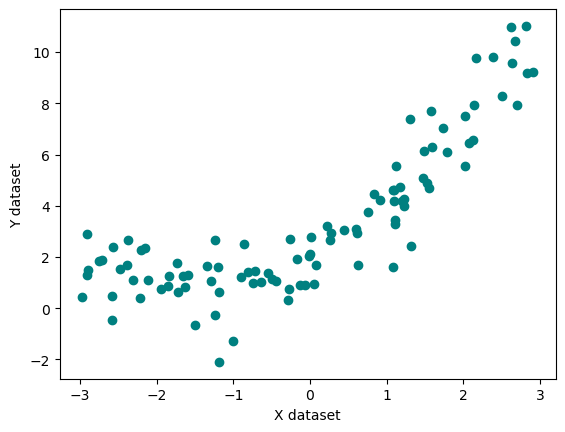

In [86]:
plt.scatter(x,y,color='teal')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [87]:
## split the x and y 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [88]:
#linear regression model 
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()


In [89]:
regression_1.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [90]:
y_pred=regression_1.predict(x_test)

In [91]:
#r2 score 
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("R2 Score when we apply simple liner regression on non-linear data:",score)


R2 Score when we apply simple liner regression on non-linear data: 0.6697381798456108


## here we can see that less accuracy beacuse the best fit line is not yet best fit along with the non-linear data so we have to apply polynomial regression

Text(0, 0.5, 'Y')

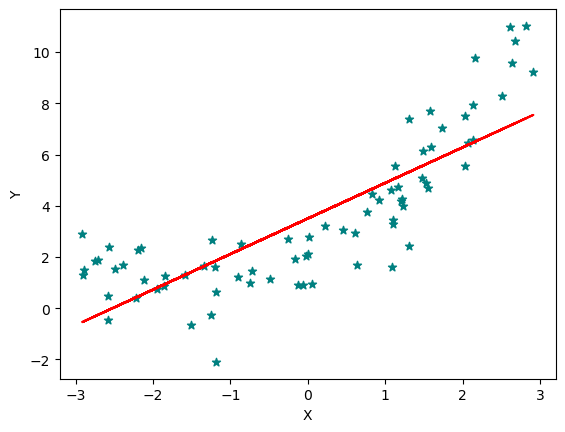

In [92]:
plt.scatter(x_train,y_train,marker='*',color='teal')
plt.plot(x_train,regression_1.predict(x_train),color='red')
plt.xlabel('X')
plt.ylabel('Y')

we can clearly see that data points are in non_linear form and best fit line is far away from large number of data points that is why less accuracy

In [93]:
## here now i will use polynomial regression to increase the degree for the best fit line
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [94]:
model=LinearRegression()
model.fit(x_train_poly,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [95]:
y_predict=model.predict(x_test_poly)

In [96]:
score=r2_score(y_test,y_predict)
print("R2 Score after applying the Polynomial Feature over the non_linear data",score)

R2 Score after applying the Polynomial Feature over the non_linear data 0.89398349046921


Text(0, 0.5, 'y')

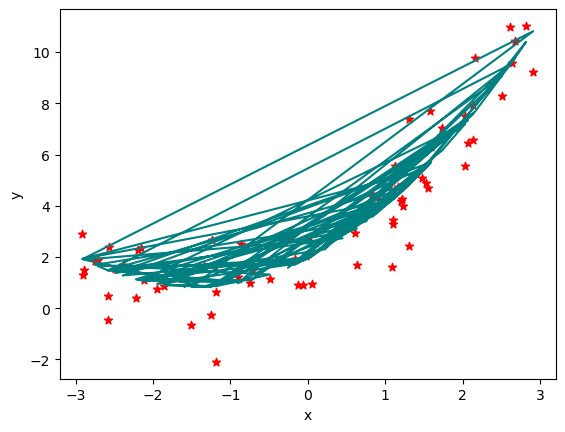

In [101]:
plt.scatter(x_train,y_train,marker='*',color='red')
plt.plot(x_train,model.predict(x_train_poly),color='teal')
plt.xlabel('x')
plt.ylabel('y')

as we can see that after applying the polynomial feature we have shifted the best fit line in such a way that all the data points are near to it and accuracy has increased